# Real-world Data Wrangling

This completed demo follows the same section order and issue-cell layout as Data_Wrangling_Project_Starter.ipynb.

It uses two small synthetic US public-library datasets. The demo intentionally contains exactly two data quality issues and two data tidiness issues. Additional pivot and melt examples appear only in the appendix so they do not change the four assessed issues.

In [1]:
# No additional package installation is required for this local demo.
# In the Udacity workspace, install matplotlib only if it is not already available.

In [2]:
import ast
from pathlib import Path

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

DATA_DIR = Path(".")
programs_path = DATA_DIR / "library_program_registrations_dirty.csv"
branches_path = DATA_DIR / "library_branch_lookup.csv"

**Note:** Keep the notebook and both CSV files in the same directory so the relative paths work.

## 1. Gather data

In this section, load the two datasets used throughout the assessment, cleaning, storage, and analysis steps.

### **1.1.** Problem Statement

Public libraries offer programs across many subjects, but registration data must be reliable and analysis-ready before program outcomes can be compared. This demo asks which program types show the strongest score gains and which learner interests appear most often.

The two datasets are intentionally small so every assessment and cleaning decision can be demonstrated live. The separate data-gathering notebook contains the ZIP, JSON, API, and Kaggle examples; this project-flow notebook begins with the two gathered CSV files.

### **1.2.** Gather at least two datasets using two different data gathering methods

For this demo, both gathered files are already stored locally. The presentation can explain their original gathering methods, while the notebook focuses on loading and wrangling the resulting data.

#### **Dataset 1**

Type: CSV file

Method: A manually downloaded registration extract.

Dataset variables:

- registration_id identifies each registration record.
- attendance_hours measures session attendance.
- interests contains list-like interest records with id and name fields.
- pre_score and post_score support learning-gain analysis.

In [3]:
# Load the registration dataset.
programs_raw = pd.read_csv(programs_path, parse_dates=["session_date"])
programs_raw.head()

,registration_id,learner_name,Age,city,branch_id,program_id,program_name,session_date,program_type,interests,registration_status,attendance_hours,pre_score,post_score,fee_paid,scholarship_amount
0,R001,Emma Johnson,8,New York,B101,P001,Intro to Python,2026-01-12,STEM,"[{'id': 9, 'name': 'coding'}, {'id': 22, 'name...",Attended,2.0,45,72,0,25
1,R002,Liam Smith,10,Los Angeles,B102,P001,Intro to Python,2026-01-20,STEM,"[{'id': 9, 'name': 'coding'}, {'id': 18, 'name...",Attended,2.5,50,80,0,25
2,R003,Olivia Brown,11,Chicago,B103,P002,Data Storytelling,2026-02-02,Data,"[{'id': 8, 'name': 'charts'}, {'id': 26, 'name...",No Show,0,60,78,5,0
3,R004,Noah Davis,7,Houston,B104,P003,Robotics Basics,2026-02-15,STEM,"[{'id': 22, 'name': 'robots'}, {'id': 27, 'nam...",Attended,1.5,40,65,0,30
4,R005,Ava Wilson,16,Phoenix,B105,P004,College Essay Lab,2026-03-05,Writing,"[{'id': 28, 'name': 'writing'}, {'id': 10, 'na...",Attended,2.0,70,88,10,0


#### Dataset 2

Type: CSV file

Method: A programmatically retrieved branch lookup export.

Dataset variables:

- branch_id is the join key.
- branch_name and branch_city identify the library branch.
- region supports geographic comparison.

In [4]:
# Load the branch lookup dataset.
branches_raw = pd.read_csv(branches_path)
branches_raw.head()

,branch_id,branch_name,branch_city,state,region,opened_year,square_feet,annual_visits,wifi_available
0,B101,Central Library,New York,NY,Northeast,1911,80000,1250000,True
1,B102,Westside Branch,Los Angeles,CA,West,1954,45000,850000,True
2,B103,Lakeview Branch,Chicago,IL,Midwest,1972,38000,620000,True
3,B104,Bayou Branch,Houston,TX,South,1985,32000,540000,False
4,B105,Desert Ridge Branch,Phoenix,AZ,West,2001,28000,410000,True


Optional data storing step: The raw CSV files remain unchanged in the local data store so the original and cleaned versions are kept separately.

In [5]:
{
    "programs_file_exists": programs_path.exists(),
    "branches_file_exists": branches_path.exists(),
    "program_rows": len(programs_raw),
    "branch_rows": len(branches_raw),
}

{'programs_file_exists': True,
 'branches_file_exists': True,
 'program_rows': 28,
 'branch_rows': 7}

## 2. Assess data

Assess exactly two data quality issues and two data tidiness issues. Each issue is inspected visually and programmatically before a cleaning strategy is selected.

### Quality Issue 1: Attendance contains missing markers and an extreme value

In [6]:
# Visual inspection: examine the raw attendance values.
programs_raw.head(20)

,registration_id,learner_name,Age,city,branch_id,program_id,program_name,session_date,program_type,interests,registration_status,attendance_hours,pre_score,post_score,fee_paid,scholarship_amount
0,R001,Emma Johnson,8,New York,B101,P001,Intro to Python,2026-01-12,STEM,"[{'id': 9, 'name': 'coding'}, {'id': 22, 'name...",Attended,2.0,45,72,0,25
1,R002,Liam Smith,10,Los Angeles,B102,P001,Intro to Python,2026-01-20,STEM,"[{'id': 9, 'name': 'coding'}, {'id': 18, 'name...",Attended,2.5,50,80,0,25
2,R003,Olivia Brown,11,Chicago,B103,P002,Data Storytelling,2026-02-02,Data,"[{'id': 8, 'name': 'charts'}, {'id': 26, 'name...",No Show,0,60,78,5,0
3,R004,Noah Davis,7,Houston,B104,P003,Robotics Basics,2026-02-15,STEM,"[{'id': 22, 'name': 'robots'}, {'id': 27, 'nam...",Attended,1.5,40,65,0,30
4,R005,Ava Wilson,16,Phoenix,B105,P004,College Essay Lab,2026-03-05,Writing,"[{'id': 28, 'name': 'writing'}, {'id': 10, 'na...",Attended,2.0,70,88,10,0
5,R006,James Miller,35,Philadelphia,B106,P005,Resume Workshop,2026-03-12,Career,"[{'id': 7, 'name': 'career'}, {'id': 28, 'name...",Attended,1.0,65,75,15,0
6,R007,Mia Garcia,9,San Antonio,B107,P003,Robotics Basics,2026-03-18,STEM,"[{'id': 22, 'name': 'robots'}, {'id': 9, 'name...",Cancelled,TBD,42,68,0,30
7,R008,William Martinez,42,San Diego,B107,P006,Small Business Data,2026-04-01,Business,"[{'id': 25, 'name': 'spreadsheets'}, {'id': 6,...",Attended,3.0,55,79,20,0
8,R009,Sophia Anderson,14,New York,B101,P002,Data Storytelling,2026-04-15,Data,"[{'id': 8, 'name': 'charts'}, {'id': 26, 'name...",Attended,2.0,58,82,5,5
9,R010,Benjamin Thomas,13,Los Angeles,B102,P004,College Essay Lab,2026-04-20,Writing,"[{'id': 10, 'name': 'college'}, {'id': 28, 'na...",Attended,2.0,73,90,10,0


In [7]:
# Programmatic inspection: discover markers before defining a missing-marker list.
attendance_as_number = pd.to_numeric(
    programs_raw["attendance_hours"],
    errors="coerce",
)

print("Nonnumeric attendance values:")
programs_raw.loc[
    attendance_as_number.isna(),
    "attendance_hours",
].value_counts(dropna=False)

Nonnumeric attendance values:


attendance_hours
TBD    1
*      1
Name: count, dtype: int64

In [8]:
print("Numeric attendance summary:")
attendance_as_number.describe()

Numeric attendance summary:


count     26.000000
mean      36.307692
std      176.160670
min        0.000000
25%        1.500000
50%        2.000000
75%        2.000000
max      900.000000
Name: attendance_hours, dtype: float64

In [9]:
print("Largest attendance values:")
programs_raw.loc[
    attendance_as_number.nlargest(5).index,
    ["registration_id", "learner_name", "attendance_hours"],
]

Largest attendance values:


,registration_id,learner_name,attendance_hours
17,R018,Amelia Hall,900
7,R008,William Martinez,3.0
1,R002,Liam Smith,2.5
13,R014,Harper Lee,2.5
27,R028,Sarah Carter,2.5


Issue and justification: The assessment discovers TBD and * as nonnumeric attendance markers, rather than assuming them in advance. It also identifies 900 hours as an extreme value using a median absolute deviation screening rule. These related problems prevent attendance_hours from being analyzed as a reliable numeric measure.

### Quality Issue 2: Duplicate registration records

In [10]:
# Visual inspection: sort the fields that define a registration.
programs_raw[[
    "registration_id", "learner_name", "program_id", "session_date"
]].sort_values(
    ["learner_name", "program_id", "session_date"]
).to_string(index=False)

'registration_id     learner_name program_id session_date\n           R020    Abigail Young       P013   2026-08-05\n           R018      Amelia Hall       P012   2026-07-09\n           R005       Ava Wilson       P004   2026-03-05\n           R010  Benjamin Thomas       P004   2026-04-20\n           R011  Benjamin Thomas       P004   2026-04-20\n           R012  Charlotte Moore       P007   2026-04-30\n           R025     Daniel Baker       P016   2026-10-16\n           R013    Elijah Taylor       P007   2026-05-10\n           R026       Ella Adams       P017   2026-11-05\n           R022     Emily Wright       P014   2026-09-02\n           R001     Emma Johnson       P001   2026-01-12\n           R016     Evelyn Lewis       P010   2026-06-15\n           R024      Grace Green       P015   2026-10-01\n           R014       Harper Lee       P008   2026-05-18\n           R021       Henry King       P013   2026-08-12\n           R023       Jack Scott       P014   2026-09-09\n           R0

In [11]:
# Programmatic inspection: identify every record in a duplicate group.
duplicate_key = ["learner_name", "program_id", "session_date"]
duplicate_mask = programs_raw.duplicated(subset=duplicate_key, keep=False)
programs_raw.loc[
    duplicate_mask,
    ["registration_id", *duplicate_key],
]

,registration_id,learner_name,program_id,session_date
9,R010,Benjamin Thomas,P004,2026-04-20
10,R011,Benjamin Thomas,P004,2026-04-20


Issue and justification: R010 and R011 describe the same learner, program, and session date. Counting both would overstate registrations and duplicate that learner's contribution to summaries.

### Tidiness Issue 1: Multiple interest records are stored in one cell

In [12]:
# Visual inspection: view the list-like interest records.
programs_raw[["registration_id", "learner_name", "interests"]].head(10)

,registration_id,learner_name,interests
0,R001,Emma Johnson,"[{'id': 9, 'name': 'coding'}, {'id': 22, 'name..."
1,R002,Liam Smith,"[{'id': 9, 'name': 'coding'}, {'id': 18, 'name..."
2,R003,Olivia Brown,"[{'id': 8, 'name': 'charts'}, {'id': 26, 'name..."
3,R004,Noah Davis,"[{'id': 22, 'name': 'robots'}, {'id': 27, 'nam..."
4,R005,Ava Wilson,"[{'id': 28, 'name': 'writing'}, {'id': 10, 'na..."
5,R006,James Miller,"[{'id': 7, 'name': 'career'}, {'id': 28, 'name..."
6,R007,Mia Garcia,"[{'id': 22, 'name': 'robots'}, {'id': 9, 'name..."
7,R008,William Martinez,"[{'id': 25, 'name': 'spreadsheets'}, {'id': 6,..."
8,R009,Sophia Anderson,"[{'id': 8, 'name': 'charts'}, {'id': 26, 'name..."
9,R010,Benjamin Thomas,"[{'id': 10, 'name': 'college'}, {'id': 28, 'na..."


In [13]:
# Programmatic inspection: parse the strings and count interest records per row.
parsed_interests = programs_raw["interests"].apply(ast.literal_eval)
interest_counts_per_row = parsed_interests.str.len()
interest_counts_per_row.value_counts().sort_index()

interests
2    28
Name: count, dtype: int64

Issue and justification: Each interests cell contains a list of two id-name dictionaries. Interest-level analysis requires one interest per row, so the strings should be parsed, the lists exploded, and the dictionary fields extracted into scalar columns.

### Tidiness Issue 2: Branch attributes are stored in a separate table

In [38]:
# Visual inspection: compare the registration and branch structures.
print("Registration columns:")
print(programs_raw.columns.tolist())
print()
print("Branch columns:")
print(branches_raw.columns.tolist())
print()
branches_raw.head()

Registration columns:
['registration_id', 'learner_name', 'Age', 'city', 'branch_id', 'program_id', 'program_name', 'session_date', 'program_type', 'interests', 'registration_status', 'attendance_hours', 'pre_score', 'post_score', 'fee_paid', 'scholarship_amount']

Branch columns:
['branch_id', 'branch_name', 'branch_city', 'state', 'region', 'opened_year', 'square_feet', 'annual_visits', 'wifi_available']



,branch_id,branch_name,branch_city,state,region,opened_year,square_feet,annual_visits,wifi_available
0,B101,Central Library,New York,NY,Northeast,1911,80000,1250000,True
1,B102,Westside Branch,Los Angeles,CA,West,1954,45000,850000,True
2,B103,Lakeview Branch,Chicago,IL,Midwest,1972,38000,620000,True
3,B104,Bayou Branch,Houston,TX,South,1985,32000,540000,False
4,B105,Desert Ridge Branch,Phoenix,AZ,West,2001,28000,410000,True


In [35]:
print("unique program branch_ids")
programs_raw["branch_id"].nunique()

unique program branch_ids


7

In [36]:
print("unique lookup branch_ids")
branches_raw["branch_id"].nunique()

unique lookup branch_ids


7

In [37]:
print("unmatched program branch_ids")
sorted(set(programs_raw["branch_id"]) - set(branches_raw["branch_id"]))

unmatched program branch_ids


[]

Issue and justification: Program rows contain only branch_id, while branch name, city, state, region, and facility attributes are stored in the lookup table. A validated many-to-one merge is required to create the analysis table.

#### Assessment Summary

- Quality Issue 1: Attendance contains missing markers and an extreme value.
- Quality Issue 2: Duplicate registration records.
- Tidiness Issue 1: Multiple interest records are stored in one cell.
- Tidiness Issue 2: Branch attributes are stored in a separate table.

## 3. Clean data

Clean the four issues identified in the assessment. Each cleanup repeats the same issue label, applies a strategy, validates the result, and explains the decision.

In [16]:
# Make copies so the raw DataFrames remain unchanged.
programs_clean = programs_raw.copy()
branches_clean = branches_raw.copy()

### **Quality Issue 1: Attendance contains missing markers and an extreme value**

In [17]:
# Apply the cleaning strategy.
missing_markers = ["TBD", "*"]
programs_clean["attendance_hours"] = (
    programs_clean["attendance_hours"]
    .replace(missing_markers, np.nan)
    .pipe(pd.to_numeric, errors="coerce")
)

attendance_median = programs_clean["attendance_hours"].median()
attendance_mad = (
    programs_clean["attendance_hours"] - attendance_median
).abs().median()
outlier_upper_bound = attendance_median + 10 * attendance_mad

programs_clean.loc[
    programs_clean["attendance_hours"] > outlier_upper_bound,
    "attendance_hours",
] = np.nan

programs_clean["attendance_hours"] = (
    programs_clean.groupby("program_type")["attendance_hours"]
    .transform(lambda values: values.fillna(values.median()))
)

In [18]:
# Validate the cleaning.
pd.Series({
    "missing_attendance_values": programs_clean["attendance_hours"].isna().sum(),
    "maximum_attendance_hours": programs_clean["attendance_hours"].max(),
    "attendance_dtype": str(programs_clean["attendance_hours"].dtype),
    "outlier_upper_bound": outlier_upper_bound,
})

missing_attendance_values          0
maximum_attendance_hours         3.0
attendance_dtype             float64
outlier_upper_bound              7.0
dtype: object

Justification: The marker list comes directly from the assessment output. After conversion, the robust upper bound flags the 900-hour value without flagging the plausible 3-hour session. Missing and flagged values are imputed with the median for the same program type so registrations are retained.

### **Quality Issue 2: Duplicate registration records**

In [19]:
# Apply the cleaning strategy using the key defined during assessment.
programs_clean = programs_clean.drop_duplicates(
    subset=duplicate_key,
    keep="last",
).copy()

In [20]:
# Validate the cleaning.
pd.Series({
    "remaining_duplicate_rows": programs_clean.duplicated(
        subset=duplicate_key,
        keep=False,
    ).sum(),
    "clean_registration_rows": len(programs_clean),
})

remaining_duplicate_rows     0
clean_registration_rows     27
dtype: int64

Justification: Keeping the last record applies a clear and reproducible rule. It leaves one registration for the duplicated learner-program-session combination.

### **Tidiness Issue 1: Multiple interest records are stored in one cell**

In [21]:
# Parse the list-like strings, explode them, and extract each record.
interests_clean = (
    programs_clean
    .assign(interests=programs_clean["interests"].apply(ast.literal_eval))
    .explode("interests", ignore_index=True)
)
interests_clean["interest_id"] = interests_clean["interests"].str["id"]
interests_clean["interest"] = interests_clean["interests"].str["name"]
interests_clean = interests_clean.drop(columns="interests")

In [22]:
# Validate the cleaning.
pd.Series({
    "missing_interest_ids": interests_clean["interest_id"].isna().sum(),
    "missing_interest_names": interests_clean["interest"].isna().sum(),
    "interest_rows": len(interests_clean),
    "unique_interests": interests_clean["interest"].nunique(),
})

missing_interest_ids       0
missing_interest_names     0
interest_rows             54
unique_interests          28
dtype: int64

Justification: literal_eval converts each stored string into a Python list, explode creates one row per registration-interest pair, and dictionary access separates the id and name into scalar columns. This mirrors the cleaning pattern used for genre records.

### **Tidiness Issue 2: Branch attributes are stored in a separate table**

In [23]:
# Apply the cleaning strategy with a validated many-to-one merge.
merged = interests_clean.merge(
    branches_clean,
    on="branch_id",
    how="left",
    validate="many_to_one",
    indicator=True,
)

In [24]:
# Validate the cleaning.
pd.Series({
    "matched_interest_rows": (merged["_merge"] == "both").sum(),
    "unmatched_interest_rows": (merged["_merge"] != "both").sum(),
    "merged_rows": len(merged),
})

matched_interest_rows      54
unmatched_interest_rows     0
merged_rows                54
dtype: int64

Justification: A many-to-one validation confirms that each branch_id maps to at most one branch record. The merge indicator confirms that every exploded interest row receives branch attributes.

### **Remove unnecessary variables and combine datasets**

The merge audit column is useful for validation but is not needed in the final dataset. The original interests column was already replaced by the scalar interest_id and interest columns during the explode cleanup.

In [25]:
# Finalize both output grains from the single validated merge.
final_dataset = merged.drop(columns="_merge").copy()
registration_level = (
    final_dataset
    .drop(columns=["interest_id", "interest"])
    .drop_duplicates(subset="registration_id")
    .copy()
)

print("Registration-level shape:", registration_level.shape)
print("Interest-level shape:", final_dataset.shape)

Registration-level shape: (27, 23)
Interest-level shape: (54, 25)


## 4. Update your data store

Preserve the raw CSV files and save clearly named cleaned versions. The registration-level file is useful for program analysis, while the interest-level file is useful for interest analysis.

In [26]:
# Save cleaned data without overwriting the raw files.
registration_clean_path = DATA_DIR / "library_programs_cleaned.csv"
interests_clean_path = DATA_DIR / "library_program_interests_cleaned.csv"

registration_level.to_csv(registration_clean_path, index=False)
final_dataset.to_csv(interests_clean_path, index=False)

print("Saved:", registration_clean_path)
print("Saved:", interests_clean_path)

Saved: library_programs_cleaned.csv
Saved: library_program_interests_cleaned.csv


## 5. Answer the research question

### **5.1:** Define and answer the research question

Use the cleaned data to compare learning outcomes by program type and learner interest frequency.

*Research question:* Which program types show the strongest average score gains, and which learner interests appear most frequently?

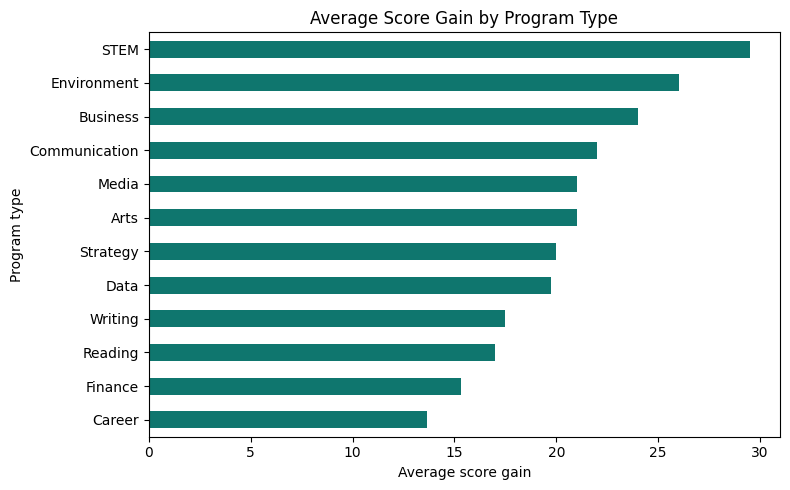

,registrations,average_score_gain
program_type,,
STEM,8,29.500000
Environment,1,26.000000
Business,1,24.000000
Communication,1,22.000000
Arts,1,21.000000
Media,1,21.000000
Strategy,1,20.000000
Data,4,19.750000
Writing,2,17.500000


In [27]:
# Visual 1: average score gain by program type.
registration_analysis = registration_level.assign(
    score_gain=(
        registration_level["post_score"]
        - registration_level["pre_score"]
    )
)
program_type_summary = (
    registration_analysis.groupby("program_type")
    .agg(
        registrations=("registration_id", "count"),
        average_score_gain=("score_gain", "mean"),
    )
    .sort_values("average_score_gain", ascending=True)
)


ax = program_type_summary["average_score_gain"].plot(
    kind="barh",
    figsize=(8, 5),
    color="#0F766E",
)
ax.set_title("Average Score Gain by Program Type")
ax.set_xlabel("Average score gain")
ax.set_ylabel("Program type")
plt.tight_layout()
plt.show()

program_type_summary.sort_values(
    "average_score_gain",
    ascending=False,
)

*Answer to research question:* STEM has the highest average score gain at 29.5 points and also has the largest number of registrations. Categories with only one registration should be interpreted cautiously because their averages are based on a single learner.

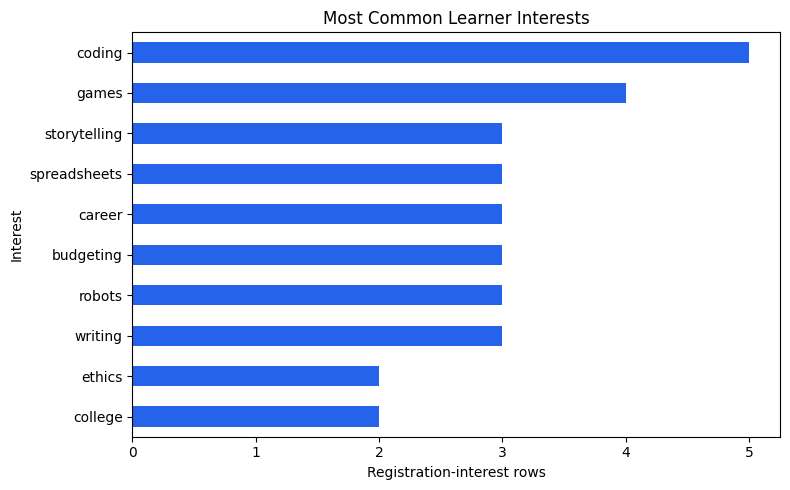

interest
coding          5
games           4
writing         3
robots          3
budgeting       3
career          3
spreadsheets    3
storytelling    3
college         2
ethics          2
Name: count, dtype: int64

In [28]:
# Visual 2: most common learner interests.
interest_summary = final_dataset["interest"].value_counts().head(10).sort_values()


ax = interest_summary.plot(
    kind="barh",
    figsize=(8, 5),
    color="#2563EB",
)
ax.set_title("Most Common Learner Interests")
ax.set_xlabel("Registration-interest rows")
ax.set_ylabel("Interest")
plt.tight_layout()
plt.show()

interest_summary.sort_values(ascending=False)

*Answer to research question:* Coding is the most common interest with 5 registration-interest rows, followed by games with 4. Robots, storytelling, budgeting, writing, spreadsheets, and career each appear 3 times.

### **5.2:** Reflection

With more time, the analysis should use a larger real-world sample and investigate whether score gains differ after controlling for age, attendance, and program size. The gathering step should also document the original source and collection method for each dataset in more detail.

*Answer:* The four demonstrated issues are intentionally limited so learners can trace every assessment directly to one cleanup. Additional transformations are kept outside the assessed project flow.

## Appendix: Advanced reshaping with melt and pivot

This appendix is not an additional assessed issue. It demonstrates how the same cleaned score data can move from wide to long format and back again.

In [29]:
# Convert pre_score and post_score from wide to long format.
scores_long = programs_clean.melt(
    id_vars=["registration_id", "learner_name", "program_type"],
    value_vars=["pre_score", "post_score"],
    var_name="assessment",
    value_name="score",
)
scores_long.head(8)

,registration_id,learner_name,program_type,assessment,score
0,R001,Emma Johnson,STEM,pre_score,45
1,R002,Liam Smith,STEM,pre_score,50
2,R003,Olivia Brown,Data,pre_score,60
3,R004,Noah Davis,STEM,pre_score,40
4,R005,Ava Wilson,Writing,pre_score,70
5,R006,James Miller,Career,pre_score,65
6,R007,Mia Garcia,STEM,pre_score,42
7,R008,William Martinez,Business,pre_score,55


In [30]:
# Pivot the long score table back to one row per registration.
scores_wide = (
    scores_long.pivot(
        index=["registration_id", "learner_name", "program_type"],
        columns="assessment",
        values="score",
    )
    .reset_index()
    .rename_axis(columns=None)
)
scores_wide.head()

,registration_id,learner_name,program_type,post_score,pre_score
0,R001,Emma Johnson,STEM,72,45
1,R002,Liam Smith,STEM,80,50
2,R003,Olivia Brown,Data,78,60
3,R004,Noah Davis,STEM,65,40
4,R005,Ava Wilson,Writing,88,70


In [31]:
# Validate the melt-pivot round trip.
expected_scores = (
    programs_clean[[
        "registration_id", "learner_name", "program_type",
        "pre_score", "post_score",
    ]]
    .sort_values("registration_id")
    .reset_index(drop=True)
)
round_trip_scores = (
    scores_wide[expected_scores.columns]
    .sort_values("registration_id")
    .reset_index(drop=True)
)

pd.testing.assert_frame_equal(
    expected_scores,
    round_trip_scores,
    check_dtype=False,
)
print("Melt-pivot round trip validated.")

Melt-pivot round trip validated.
